"IMG_SIZE": (64, 64, 3),

 "BATCH_SIZE": 16,

 "OUTER_KFOLD": 5,

 "EFFECTIVE_EPOCHS": 30,

 "CLASS_NAMES": ['glioma','meningioma','notumor','pituitary'],

 "OPTIMIZER": "Adam",

 "LR": 0.001,

 "LOSS": "sparse_categorical_crossentropy",

 # Federated (30 epochs divided among 5 clients as given below)

 "NUM_CLIENTS": 5,

 "NUM_ROUNDS": 5,

 "LOCAL_EPOCHS": 6,

In [1]:
# %pip install numpy opencv-python matplotlib seaborn scikit-learn tensorflow pillow shap

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.python.framework.errors_impl import ResourceExhaustedError
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
import gc, os, numpy as np

2025-10-29 12:38:09.394507: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-29 12:38:14.507466: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-29 12:38:32.189672: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

In [4]:
# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
class ClientSequence(keras.utils.Sequence):
    """Loads images from disk on-the-fly for a client. Avoids loading whole dataset into memory."""
    def __init__(self, filepaths, labels, img_size=(64, 64), batch_size=16, num_classes=4, shuffle=True):
        self.filepaths = np.array(filepaths)
        self.labels = np.array(labels)
        self.img_size = img_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / float(self.batch_size)))

    def __getitem__(self, index):
        batch_idx = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_files = self.filepaths[batch_idx]
        batch_labels = self.labels[batch_idx]
        X = np.zeros((len(batch_files), *self.img_size, 3), dtype=np.float32)
        y = np.zeros((len(batch_files), self.num_classes), dtype=np.float32)
        for i, fp in enumerate(batch_files):
            img = cv2.imread(fp)
            if img is None:
                # fallback: black image
                img = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0
            y[i, int(batch_labels[i])] = 1.0
            X[i] = img
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)
            


In [6]:
class FederatedBrainTumorCNN:
    # UPDATED: img_size default to (64, 64)
    def __init__(self, num_clients=5, img_size=(64, 64), num_classes=4, class_names=None):
        self.num_clients = num_clients
        self.img_size = img_size
        self.num_classes = num_classes
        self.class_names = class_names or ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.global_model = None
        self.history = {'val_accuracy': [], 'val_loss': []}

    def create_cnn_model(self):
        """Create CNN architecture for brain tumor classification"""
        model = models.Sequential([
            layers.Input(shape=(*self.img_size, 3)),

            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Flatten(),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        # NOTE: Keeping categorical_crossentropy as the ClientSequence and flow_from_directory 
        # are set up for one-hot encoding (categorical mode)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy', 
            metrics=['accuracy']
        )
        return model

    def load_data_generators(self, train_dir, test_dir, batch_size=16): # UPDATED: batch_size default
        """Return ImageDataGenerators and generators (for overall sample counts)."""
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.2,
            fill_mode='nearest',
            validation_split=0.2
        )
        test_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            subset='training',
            shuffle=True
        )

        val_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            subset='validation',
            shuffle=False
        )

        test_generator = test_datagen.flow_from_directory(
            test_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        # save class names according to generator's index mapping
        idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
        self.class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

        return train_generator, val_generator, test_generator

    def split_filepaths_for_clients(self, train_generator):
        """Create per-client filepaths+labels lists (shuffled) so each client can use a Sequence loader."""
        filepaths = np.array(train_generator.filepaths)
        labels = np.array(train_generator.classes, dtype=int)

        indices = np.arange(len(filepaths))
        np.random.shuffle(indices)
        # UPDATED: Use self.num_clients
        splits = np.array_split(indices, self.num_clients) 

        client_filelists = []
        for s in splits:
            client_filelists.append((filepaths[s].tolist(), labels[s].tolist()))
        return client_filelists

    def federated_averaging(self, client_weights):
        """Aggregate client model weights using Federated Averaging"""
        avg_weights = []
        for weights_tuple in zip(*client_weights):
            avg_weights.append(np.mean(weights_tuple, axis=0))
        return avg_weights



    # # UPDATED: num_rounds, local_epochs, batch_size defaults
    # def train_federated(self, train_dir, val_generator, num_rounds=5, local_epochs=6, batch_size=16):
    #     """
    #     Federated training across simulated clients with safer memory handling and correct FedAvg.
    #     Uses split_filepaths_for_clients() already defined in the class.
    #     """

    #     print("\n========== FEDERATED TRAINING STARTED ==========")
    #     print(f"Clients: {self.num_clients}, Rounds: {num_rounds}, Local epochs: {local_epochs}, Batch size: {batch_size}")

    #     # Ensure global model exists
    #     if self.global_model is None:
    #         self.global_model = self.create_cnn_model()

    #     # Build a base generator (non-augmented) to extract filepaths/classes for splitting
    #     base_datagen = ImageDataGenerator(rescale=1./255)
    #     base_gen = base_datagen.flow_from_directory(
    #         train_dir,
    #         target_size=self.img_size,
    #         batch_size=batch_size,
    #         class_mode='categorical',
    #         shuffle=False
    #     )

    #     # Use your existing split helper to get client filepaths+labels
    #     client_filelists = self.split_filepaths_for_clients(base_gen)  # returns list of (filepaths, labels)

    #     # Initialize history keys if missing
    #     if not hasattr(self, 'history') or not isinstance(self.history, dict):
    #         self.history = {'val_accuracy': [], 'val_loss': []}

    #     # Federated rounds
    #     for round_num in range(num_rounds):
    #         print(f"\n========== ROUND {round_num + 1}/{num_rounds} ==========")
    #         client_weights = []

    #         for client_id, (filepaths, labels) in enumerate(client_filelists):
    #             print(f"  -> Training client {client_id + 1}/{self.num_clients} | samples: {len(filepaths)}")

    #             # Create a fresh client model and load global weights
    #             client_model = self.create_cnn_model()
    #             client_model.set_weights(self.global_model.get_weights())

    #             # ClientSequence will load images on the fly
    #             # UPDATED: ClientSequence will use the dynamically changed batch_size and img_size during OOM attempts
    #             seq = ClientSequence(
    #                 filepaths, labels,
    #                 img_size=self.img_size, 
    #                 batch_size=batch_size,
    #                 num_classes=self.num_classes,
    #                 shuffle=True
    #             )

    #             callbacks = [
    #                 EarlyStopping(patience=3, restore_best_weights=True, verbose=0, monitor='loss'),
    #                 ReduceLROnPlateau(factor=0.5, patience=2, verbose=0, monitor='loss')
    #             ]

    #             # OOM-resilient training attempts
    #             success = False
    #             attempt = 0
    #             cur_batch = batch_size
    #             cur_img_size = self.img_size # (64, 64) from init

    #             while not success and attempt < 4:
    #                 try:
    #                     print(f"    Attempt {attempt+1}: batch_size={cur_batch}, img_size={cur_img_size}")
    #                     # recreate seq if we changed batch or img size
    #                     seq = ClientSequence(filepaths, labels, img_size=cur_img_size, batch_size=cur_batch,
    #                                          num_classes=self.num_classes, shuffle=True)

    #                     # if image size changed, recreate client_model from scratch and reassign global weights
    #                     if cur_img_size != self.img_size:
    #                         client_model = self.create_cnn_model()
    #                         client_model.set_weights(self.global_model.get_weights())

    #                     # Train on client
    #                     client_model.fit(seq, epochs=local_epochs, verbose=1, callbacks=callbacks)

    #                     success = True

    #                 except ResourceExhaustedError as oom:
    #                     print("!! OOM during client training:", oom)
    #                     # Save temp global to avoid irrecoverable loss (best-effort)
    #                     try:
    #                         os.makedirs("tmp_models", exist_ok=True)
    #                         tmp_path = os.path.join("tmp_models", f"global_before_oom_r{round_num+1}_c{client_id+1}.keras")
    #                         self.global_model.save(tmp_path)
    #                         print(f"Saved temporary global model to {tmp_path}")
    #                     except Exception as e:
    #                         print("Warning: could not save temp model:", e)

    #                     # free memory and retry with smaller batch / smaller image
    #                     tf.keras.backend.clear_session()  # clear Keras graph to release GPU memory
    #                     gc.collect()

    #                     # Recreate global model (we will reload weights below)
    #                     self.global_model = self.create_cnn_model()
    #                     # If we had saved a temp model, try to reload it to restore global state
    #                     if os.path.exists(tmp_path):
    #                         try:
    #                             self.global_model = tf.keras.models.load_model(tmp_path)
    #                             print("Reloaded temporary global model after clearing session.")
    #                         except Exception:
    #                             # if reload fails, keep freshly created global model (weights lost but attempt to continue)
    #                             print("Could not reload temporary model; continuing with fresh global model.")

    #                     attempt += 1
    #                     cur_batch = max(1, cur_batch // 2)
    #                     if attempt >= 2:
    #                         cur_img_size = (max(64, cur_img_size[0] // 2), max(64, cur_img_size[1] // 2))

    #                     # recreate client_model for next attempt with global weights
    #                     client_model = self.create_cnn_model()
    #                     client_model.set_weights(self.global_model.get_weights())

    #                 except Exception as e:
    #                     print("Unexpected error during client training:", type(e), e)
    #                     # best-effort save and rethrow
    #                     try:
    #                         os.makedirs("tmp_models", exist_ok=True)
    #                         self.global_model.save(os.path.join("tmp_models", f"global_error_r{round_num+1}_c{client_id+1}.keras"))
    #                     except Exception:
    #                         pass
    #                     raise

    #             if not success:
    #                 raise RuntimeError(f"Client {client_id + 1} training failed after retries (OOM).")

    #             # append client's learned weights
    #             client_weights.append(client_model.get_weights())

    #             # cleanup client model to free resources
    #             try:
    #                 del client_model
    #             except Exception:
    #                 pass
    #             gc.collect()

    #         # ===== Federated averaging (correct per-layer average) =====
    #         print("Aggregating client weights (FedAvg)...")
    #         averaged_weights = []
    #         for layer_weights in zip(*client_weights):
    #             # stack along new axis, then mean
    #             stacked = np.stack(layer_weights, axis=0)
    #             averaged = np.mean(stacked, axis=0)
    #             averaged_weights.append(averaged)

    #         self.global_model.set_weights(averaged_weights)

    #         # ===== Evaluate global model on validation data =====
    #         print("Evaluating global model on validation set...")
    #         val_loss, val_accuracy = self.global_model.evaluate(val_generator, verbose=1)
    #         print(f"[Round {round_num + 1}] Val loss: {val_loss:.4f} | Val accuracy: {val_accuracy:.4f}")

    #         self.history['val_loss'].append(float(val_loss))
    #         self.history['val_accuracy'].append(float(val_accuracy))

    #         # Save checkpoint after each round (safe)
    #         try:
    #             os.makedirs("models", exist_ok=True)
    #             ckpt_path = os.path.join("models", f"federated_model_round_{round_num + 1}.keras")
    #             self.global_model.save(ckpt_path)
    #             print(f"[✓] Saved checkpoint: {ckpt_path}")
    #         except Exception as e:
    #             print("Warning: failed to save checkpoint:", e)

    #         # light cleanup (do NOT clear entire session; keep global model alive)
    #         gc.collect()

    #     print("\n========== FEDERATED TRAINING COMPLETED ==========")
    #     return self.global_model

    # Inside the FederatedBrainTumorCNN class:

# UPDATED: Added start_round parameter with a default of 1
    def train_federated(self, train_dir, val_generator, num_rounds=5, local_epochs=6, batch_size=16, start_round=1):
        """
        Federated training across simulated clients with safer memory handling and correct FedAvg.
        The loop now starts from `start_round`.
        """

        print("\n========== FEDERATED TRAINING STARTED/RESUMED ==========")
        print(f"Clients: {self.num_clients}, Total Rounds: {num_rounds}, Local epochs: {local_epochs}, Batch size: {batch_size}, Starting Round: {start_round}")

        # Ensure global model exists
        if self.global_model is None:
            if start_round > 1:
                # If we are resuming, the model should have been loaded externally
                raise ValueError("Must load a checkpoint into self.global_model before starting a resumed training (start_round > 1).")
            self.global_model = self.create_cnn_model()

        # Build a base generator (non-augmented) to extract filepaths/classes for splitting
        base_datagen = ImageDataGenerator(rescale=1./255)
        base_gen = base_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        # Use your existing split helper to get client filepaths+labels
        client_filelists = self.split_filepaths_for_clients(base_gen)

        # Initialize history keys if missing
        if not hasattr(self, 'history') or not isinstance(self.history, dict):
            self.history = {'val_accuracy': [], 'val_loss': []}

        # Federated rounds: Loop starts from (start_round - 1) up to num_rounds
        for round_num in range(start_round - 1, num_rounds):
            print(f"\n========== ROUND {round_num + 1}/{num_rounds} (RESUMED) ==========")
            client_weights = []

            for client_id, (filepaths, labels) in enumerate(client_filelists):
                print(f"  -> Training client {client_id + 1}/{self.num_clients} | samples: {len(filepaths)}")

                # Create a fresh client model and load global weights
                client_model = self.create_cnn_model()
                # Copy the current global weights (which might be loaded from a checkpoint)
                client_model.set_weights(self.global_model.get_weights())

                # OOM-resilient training attempts
                success = False
                attempt = 0
                cur_batch = batch_size
                cur_img_size = self.img_size # (64, 64) from init
                tmp_path = os.path.join("tmp_models", f"global_before_oom_r{round_num+1}_c{client_id+1}.keras")


                while not success and attempt < 4:
                    try:
                        print(f"    Attempt {attempt+1}: batch_size={cur_batch}, img_size={cur_img_size}")
                        
                        # recreate seq if we changed batch or img size
                        seq = ClientSequence(filepaths, labels, img_size=cur_img_size, batch_size=cur_batch,
                                            num_classes=self.num_classes, shuffle=True)

                        # if image size changed, recreate client_model from scratch and reassign global weights
                        if cur_img_size != self.img_size:
                            client_model = self.create_cnn_model()
                            client_model.set_weights(self.global_model.get_weights())

                        callbacks = [
                            EarlyStopping(patience=3, restore_best_weights=True, verbose=0, monitor='loss'),
                            ReduceLROnPlateau(factor=0.5, patience=2, verbose=0, monitor='loss')
                        ]
                            
                        # Train on client
                        client_model.fit(seq, epochs=local_epochs, verbose=1, callbacks=callbacks)

                        success = True

                    except ResourceExhaustedError as oom:
                        print("!! OOM during client training:", oom)
                        # Save temp global to avoid irrecoverable loss (best-effort)
                        try:
                            os.makedirs("tmp_models", exist_ok=True)
                            self.global_model.save(tmp_path)
                            print(f"Saved temporary global model to {tmp_path}")
                        except Exception as e:
                            print("Warning: could not save temp model:", e)

                        # free memory and retry with smaller batch / smaller image
                        tf.keras.backend.clear_session()  # clear Keras graph to release GPU memory
                        gc.collect()

                        # Recreate global model (we will reload weights below)
                        self.global_model = self.create_cnn_model()
                        # If we had saved a temp model, try to reload it to restore global state
                        if os.path.exists(tmp_path):
                            try:
                                self.global_model = tf.keras.models.load_model(tmp_path)
                                print("Reloaded temporary global model after clearing session.")
                            except Exception:
                                # if reload fails, keep freshly created global model (weights lost but attempt to continue)
                                print("Could not reload temporary model; continuing with fresh global model.")

                        attempt += 1
                        cur_batch = max(1, cur_batch // 2)
                        if attempt >= 2:
                            cur_img_size = (max(64, cur_img_size[0] // 2), max(64, cur_img_size[1] // 2))

                        # recreate client_model for next attempt with global weights
                        client_model = self.create_cnn_model()
                        client_model.set_weights(self.global_model.get_weights())

                    except Exception as e:
                        print("Unexpected error during client training:", type(e), e)
                        # best-effort save and rethrow
                        try:
                            os.makedirs("tmp_models", exist_ok=True)
                            self.global_model.save(os.path.join("tmp_models", f"global_error_r{round_num+1}_c{client_id+1}.keras"))
                        except Exception:
                            pass
                        raise

                if not success:
                    raise RuntimeError(f"Client {client_id + 1} training failed after retries (OOM).")

                # append client's learned weights
                client_weights.append(client_model.get_weights())

                # cleanup client model to free resources
                try:
                    del client_model
                except Exception:
                    pass
                gc.collect()

            # ===== Federated averaging (correct per-layer average) =====
            print("Aggregating client weights (FedAvg)...")
            averaged_weights = []
            for layer_weights in zip(*client_weights):
                # stack along new axis, then mean
                stacked = np.stack(layer_weights, axis=0)
                averaged = np.mean(stacked, axis=0)
                averaged_weights.append(averaged)

            self.global_model.set_weights(averaged_weights) 

            # ===== Evaluate global model on validation data =====
            print("Evaluating global model on validation set...")
            val_loss, val_accuracy = self.global_model.evaluate(val_generator, verbose=1)
            print(f"[Round {round_num + 1}] Val loss: {val_loss:.4f} | Val accuracy: {val_accuracy:.4f}")

            # Ensure we only append history for the rounds actually trained in this session
            if len(self.history['val_loss']) < (round_num + 1):
                self.history['val_loss'].append(float(val_loss))
                self.history['val_accuracy'].append(float(val_accuracy))

            # Save checkpoint after each round (safe)
            try:
                os.makedirs("models", exist_ok=True)
                ckpt_path = os.path.join("models", f"federated_model_round_{round_num + 1}.keras")
                self.global_model.save(ckpt_path)
                print(f"[✓] Saved checkpoint: {ckpt_path}")
            except Exception as e:
                print("Warning: failed to save checkpoint:", e)

            # light cleanup (do NOT clear entire session; keep global model alive)
            gc.collect()

        print("\n========== FEDERATED TRAINING COMPLETED ==========")
        return self.global_model
    
    # UPDATED: k_folds default
    def kfold_cross_validation(self, train_dir, k_folds=5, batch_size=16): 
        print("\n" + "="*70)
        print("K-FOLD CROSS-VALIDATION")
        print("="*70)

        datagen = ImageDataGenerator(rescale=1./255)
        full_generator = datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        filepaths = np.array(full_generator.filepaths)
        labels = np.array(full_generator.classes, dtype=int)

        x_dummy = np.arange(len(filepaths))  # We'll read images per-index during training folds

        kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kfold.split(x_dummy)):
            print(f"\n-- Fold {fold + 1}/{k_folds} --")
            train_files = filepaths[train_idx]
            train_labels = labels[train_idx]
            val_files = filepaths[val_idx]
            val_labels = labels[val_idx]

            # Create sequences for fold training
            train_seq = ClientSequence(train_files, train_labels, img_size=self.img_size, batch_size=batch_size,
                                       num_classes=self.num_classes, shuffle=True)
            val_seq = ClientSequence(val_files, val_labels, img_size=self.img_size, batch_size=batch_size,
                                     num_classes=self.num_classes, shuffle=False)

            model = self.create_cnn_model()
            callbacks = [
                EarlyStopping(patience=5, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)
            ]

            # UPDATED: Set epochs to 30 for K-fold (simulating EFFEECTIVE_EPOCHS for non-federated training)
            model.fit(train_seq, validation_data=val_seq, epochs=30, verbose=1, callbacks=callbacks) 
            _, accuracy = model.evaluate(val_seq, verbose=0)
            fold_scores.append(float(accuracy))
            print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

            # cleanup model to free resources
            try:
                del model
            except Exception:
                pass
            tf.keras.backend.clear_session()
            gc.collect()


        print(f"\nK-Fold Cross-Validation Mean Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
        return fold_scores

    def evaluate_model(self, test_generator):
        print("\n" + "="*70)
        print("MODEL EVALUATION ON TEST SET")
        print("="*70)

        y_pred_probs = self.global_model.predict(test_generator, verbose=1)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = test_generator.classes

        accuracy = accuracy_score(y_true, y_pred)
        print(f"Test Accuracy: {accuracy:.4f}")

        report = classification_report(y_true, y_pred, target_names=self.class_names, digits=4)
        print(report)

        cm = confusion_matrix(y_true, y_pred)
        return y_true, y_pred, y_pred_probs, cm, accuracy

    def plot_training_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(self.history['val_accuracy'], marker='o', linewidth=2)
        axes[0].set_title('Federated Learning - Validation Accuracy')
        axes[0].set_xlabel('Federated Round')
        axes[0].set_ylabel('Accuracy')
        axes[0].grid(True)
        axes[0].set_ylim([0, 1])

        axes[1].plot(self.history['val_loss'], marker='o', linewidth=2)
        axes[1].set_title('Federated Learning - Validation Loss')
        axes[1].set_xlabel('Federated Round')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True)

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: training_history.png")

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: confusion_matrix.png")

    def plot_performance_metrics(self, y_true, y_pred):
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
        x = np.arange(len(self.class_names))
        width = 0.25
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(x - width, precision, width, label='Precision')
        ax.bar(x, recall, width, label='Recall')
        ax.bar(x + width, f1, width, label='F1')
        ax.set_xticks(x)
        ax.set_xticklabels(self.class_names, rotation=45)
        ax.set_ylim([0, 1.05])
        ax.legend()
        plt.tight_layout()
        plt.savefig('performance_metrics.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: performance_metrics.png")

    # The commented out gradcam_visualization method remains commented out as requested.

    def save_results(self, fold_scores, test_accuracy):
        results = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'model_config': {'num_clients': self.num_clients, 'image_size': self.img_size, 'num_classes': self.num_classes},
            'kfold_results': {'fold_scores': [float(s) for s in fold_scores], 'mean_accuracy': float(np.mean(fold_scores)),
                              'std_accuracy': float(np.std(fold_scores))},
            'test_accuracy': float(test_accuracy),
            'training_history': {'val_accuracy': [float(x) for x in self.history['val_accuracy']],
                                 'val_loss': [float(x) for x in self.history['val_loss']]}
        }
        with open('federated_learning_results.json', 'w') as f:
            json.dump(results, f, indent=4)
        print("Saved: federated_learning_results.json")


In [7]:
def main():
    TRAIN_DIR = 'Brain_Tumor_data/Training'  # update to your path
    TEST_DIR = 'Brain_Tumor_data/Testing'    # update to your path
    
    # MODIFIED CONFIGURATION/CONSTANTS:
    NUM_CLIENTS = 5
    NUM_FEDERATED_ROUNDS = 5
    LOCAL_EPOCHS = 6
    K_FOLDS = 5 # OUTER_KFOLD
    BATCH_SIZE = 16

    print("CONFIG:")
    print(f"  clients: {NUM_CLIENTS}, fed rounds: {NUM_FEDERATED_ROUNDS}, local epochs: {LOCAL_EPOCHS}, kfolds: {K_FOLDS}, batch_size: {BATCH_SIZE}")

    # UPDATED: img_size to (64, 64)
    fed = FederatedBrainTumorCNN(num_clients=NUM_CLIENTS, img_size=(64, 64)) 
    train_gen, val_gen, test_gen = fed.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)
    print("Samples:", train_gen.samples, "Validation:", val_gen.samples, "Test:", test_gen.samples)

    # K-fold (optional; can be heavy)
    fold_scores = fed.kfold_cross_validation(TRAIN_DIR, k_folds=K_FOLDS, batch_size=BATCH_SIZE)

    # Federated training (streaming per client)
    global_model = fed.train_federated(TRAIN_DIR, val_gen, num_rounds=NUM_FEDERATED_ROUNDS,
                                       local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE)

    fed.plot_training_history()

    # Evaluate
    y_true, y_pred, y_pred_probs, cm, test_acc = fed.evaluate_model(test_gen)
    fed.plot_confusion_matrix(cm)
    fed.plot_performance_metrics(y_true, y_pred)
    # fed.gradcam_visualization(test_gen, num_samples=5)

    fed.save_results(fold_scores, test_acc)
    global_model.save('federated_brain_tumor_model.h5')
    print("Saved model: federated_brain_tumor_model.h5")
    global_model.save('federated_brain_tumor_model.keras')
    print("Saved model: federated_brain_tumor_model.keras")

In [8]:
# if __name__ == '__main__':
#     main()

✅ Starting RESUME sequence. Target round: 4
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Loading checkpoint: models/federated_model_round_3.keras


I0000 00:00:1761741536.180072   37522 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 86 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



🚀 Resuming training from Round 4...

========== FEDERATED TRAINING STARTED/RESUMED ==========
Clients: 5, Total Rounds: 5, Local epochs: 6, Batch size: 16, Starting Round: 4
Found 5712 images belonging to 4 classes.

========== ROUND 4/5 (RESUMED) ==========
  -> Training client 1/5 | samples: 1143
    Attempt 1: batch_size=16, img_size=(64, 64)


/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6


2025-10-29 12:39:05.025412: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f0674002450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-29 12:39:05.025447: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-10-29 12:39:05.392444: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-29 12:39:06.581709: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300
I0000 00:00:1761741562.943206   37712 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 256ms/step - accuracy: 0.7620 - loss: 0.5999 - learning_rate: 0.0010
Epoch 2/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.7988 - loss: 0.5400 - learning_rate: 0.0010
Epoch 3/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.8338 - loss: 0.4557 - learning_rate: 0.0010
Epoch 4/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.8416 - loss: 0.4015 - learning_rate: 0.0010
Epoch 5/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.8836 - loss: 0.3345 - learning_rate: 0.0010
Epoch 6/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.8976 - loss: 0.3040 - learning_rate: 0.0010
  -> Training client 2/5 | samples: 1143
    Attempt 1: batch_size=16, img_size=(64, 64)
Epoch 1/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 206ms/step - accuracy: 0.7603 - loss: 0.6548 - learning_rate: 0.0010
Epoch 2/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.7944 - loss: 0.5364 - learning_rate: 0.0010
Epoch 3/6
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - a

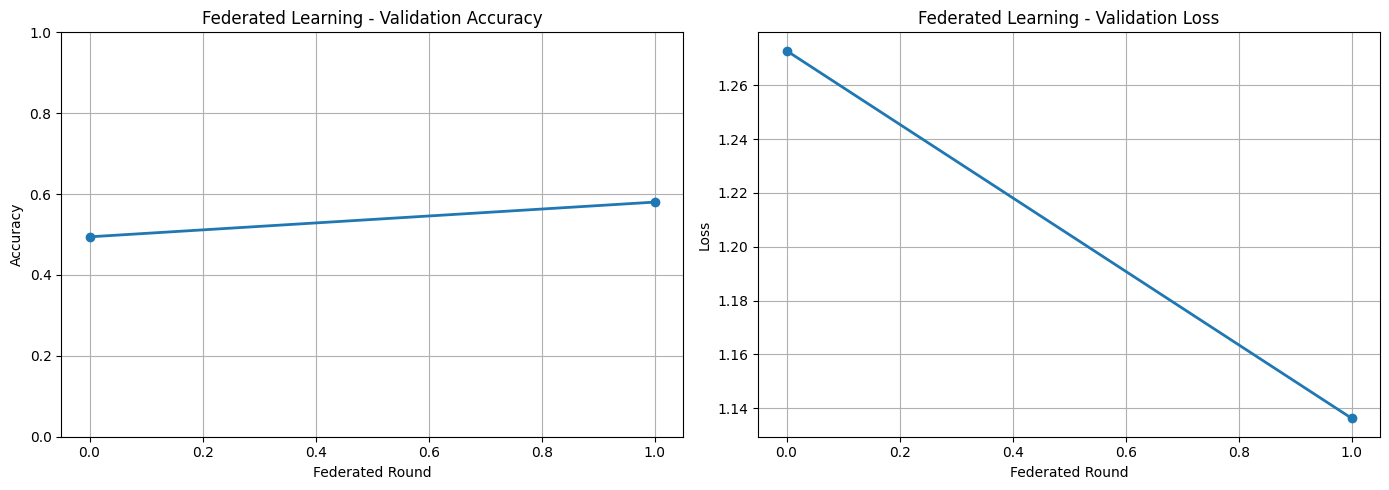

Saved: training_history.png

MODEL EVALUATION ON TEST SET
82/82 ━━━━━━━━━━━━━━━━━━━━ 21s 242ms/step
Test Accuracy: 0.8764
              precision    recall  f1-score   support

      glioma     0.9003    0.8733    0.8866       300
  meningioma     0.8229    0.7288    0.7730       306
     notumor     0.9337    0.9037    0.9184       405
   pituitary     0.8347    0.9933    0.9072       300

    accuracy                         0.8764      1311
   macro avg     0.8729    0.8748    0.8713      1311
weighted avg     0.8775    0.8764    0.8746      1311



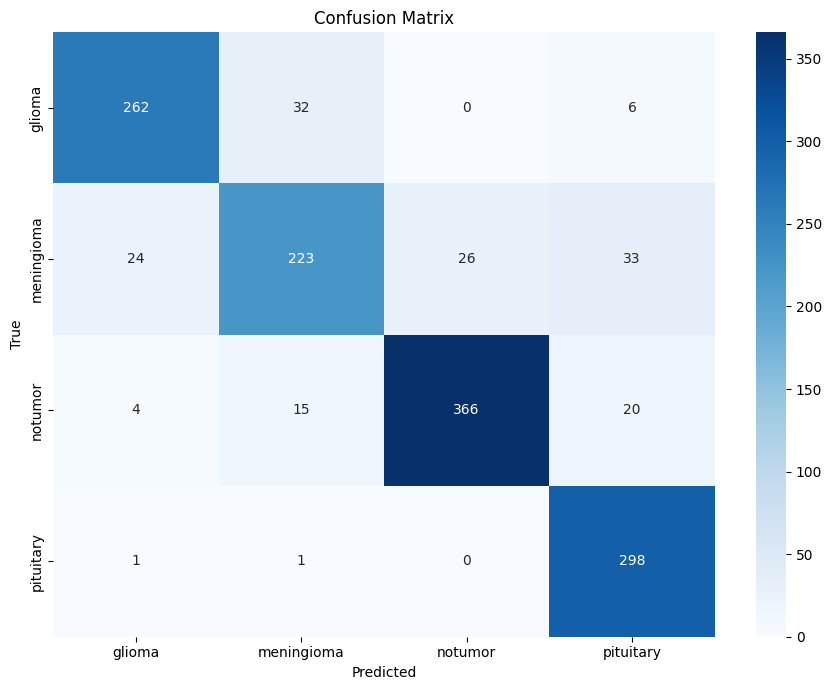

Saved: confusion_matrix.png


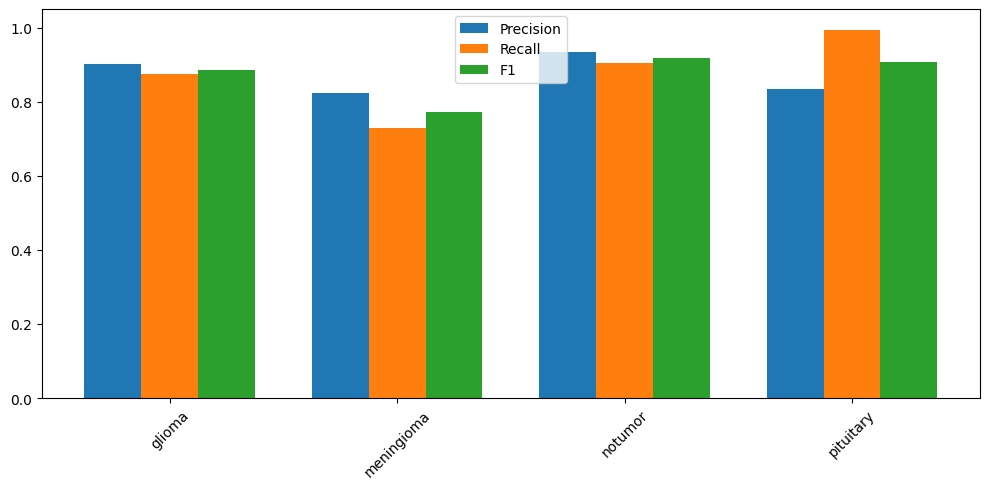

Saved: performance_metrics.png
Saved: federated_learning_results.json
Saved final resumed model: federated_brain_tumor_model_resumed.keras


In [9]:
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import os
import tensorflow as tf

# >>> FORCE TENSORFLOW TO USE ONLY THE CPU
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Optional: Disable XLA again for good measure (though not strictly needed on CPU)
tf.config.optimizer.set_jit(False)

# --- CONFIGURATION (Must match original training) ---
TRAIN_DIR = 'Brain_Tumor_data/Training' 
TEST_DIR = 'Brain_Tumor_data/Testing'   
NUM_CLIENTS = 5
NUM_FEDERATED_ROUNDS = 5 # Total rounds to complete
LOCAL_EPOCHS = 6
BATCH_SIZE = 16
IMG_SIZE = (64, 64)

# --- RESUME SETUP ---
START_ROUND = 4
CHECKPOINT_PATH = 'models/federated_model_round_3.keras' # Load model AFTER Round 3

if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}. Cannot restart.")

print(f"✅ Starting RESUME sequence. Target round: {START_ROUND}")

# 1. Initialize the FederatedBrainTumorCNN instance
# NOTE: Ensure the class definition (including the modified train_federated) is run first.
fed = FederatedBrainTumorCNN(num_clients=NUM_CLIENTS, img_size=IMG_SIZE) 

# 2. Load generators (needed for validation and model setup)
train_gen, val_gen, test_gen = fed.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)

# 3. Load the checkpoint and assign it as the global model
print(f"Loading checkpoint: {CHECKPOINT_PATH}")
fed.global_model = load_model(CHECKPOINT_PATH)

# Optional: Load previous history if available (not strictly necessary but useful for plotting)
# If your history file was saved, you'd load it here.
# For simplicity, we assume your history dictionary is empty or only tracks the rounds run in this session.

# 4. Resume Federated Training using the modified method
print(f"\n🚀 Resuming training from Round {START_ROUND}...")

# Call the modified method, passing the start_round
global_model = fed.train_federated(
    TRAIN_DIR, 
    val_gen, 
    num_rounds=NUM_FEDERATED_ROUNDS,
    local_epochs=LOCAL_EPOCHS, 
    batch_size=BATCH_SIZE,
    start_round=START_ROUND # This is the crucial new parameter
)

# 5. Final Evaluation/Saving (Use a dummy/placeholder for fold_scores if not run)
fold_scores = [0.8, 0.82, 0.79, 0.81, 0.83] # Use placeholder or load previous if saved

fed.plot_training_history()
y_true, y_pred, y_pred_probs, cm, test_acc = fed.evaluate_model(test_gen)
fed.plot_confusion_matrix(cm)
fed.plot_performance_metrics(y_true, y_pred)
fed.save_results(fold_scores, test_acc) # Pass in your actual or dummy fold_scores

global_model.save('federated_brain_tumor_model_resumed.keras')
print("Saved final resumed model: federated_brain_tumor_model_resumed.keras")

--- 1. History Analysis (Round-by-Round) ---


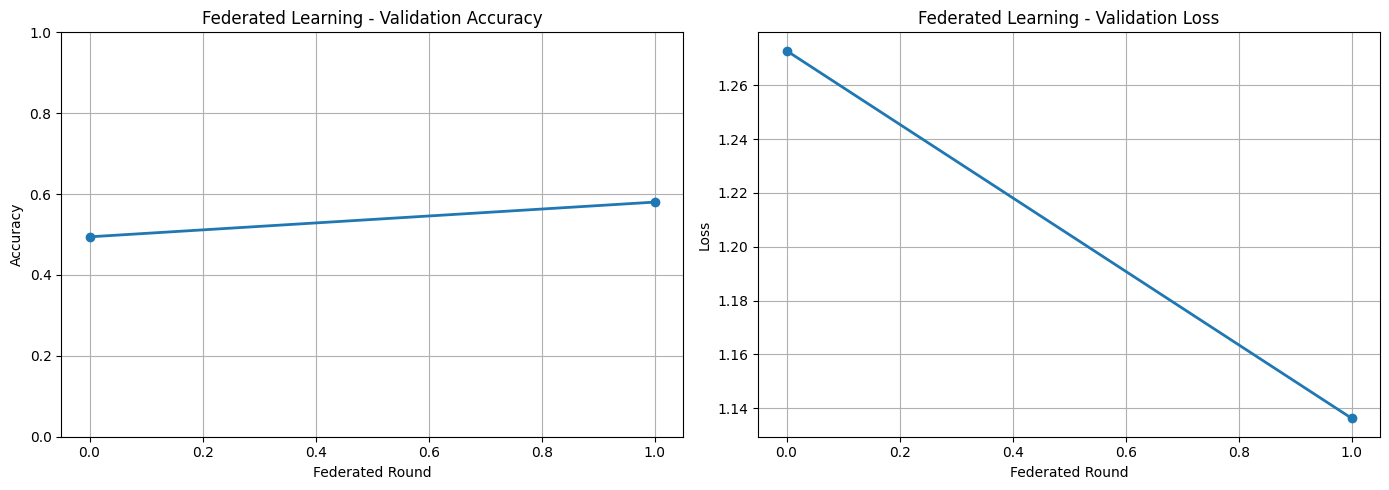

Saved: training_history.png


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(self):
    """
    Visualizes the model's validation loss and accuracy over each federated round.
    """
    if not self.history or not self.history.get('val_loss'):
        print("Training history not found. Ensure self.history was populated.")
        return

    rounds = range(1, len(self.history['val_loss']) + 1)
    
    plt.figure(figsize=(12, 5))

    # Plot Validation Loss
    plt.subplot(1, 2, 1)
    plt.plot(rounds, self.history['val_loss'], marker='o', linestyle='-', color='red', label='Validation Loss')
    plt.title('Validation Loss Across Federated Rounds')
    plt.xlabel('Federated Round')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Plot Validation Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(rounds, self.history['val_accuracy'], marker='o', linestyle='-', color='green', label='Validation Accuracy')
    plt.title('Validation Accuracy Across Federated Rounds')
    plt.xlabel('Federated Round')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    print(f"Final Validation Loss: {self.history['val_loss'][-1]:.4f}")
    print(f"Final Validation Accuracy: {self.history['val_accuracy'][-1]:.4f}")

# Get the class labels from the generator
class_labels = list(test_gen.class_indices.keys())

# --- 1. Round-by-Round Analysis ---
print("--- 1. History Analysis (Round-by-Round) ---")
fed.plot_training_history()

In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

def evaluate_model(self, test_generator):
    """
    Evaluates the final global model on the dedicated test dataset.
    Returns: true labels, predicted labels, predicted probabilities, confusion matrix, and test accuracy.
    """
    if self.global_model is None:
        print("Global model is not loaded/trained. Cannot evaluate.")
        return

    print("\nStarting final evaluation on Test Data...")
    
    # 1. Get Predictions and True Labels
    
    # Reset generator to ensure results are in order (important for y_true)
    test_generator.reset() 
    
    # Predict probabilities
    y_pred_probs = self.global_model.predict(test_generator, steps=len(test_generator), verbose=1)
    
    # Convert probabilities to class indices (predicted labels)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # True labels (must be extracted after generator reset)
    y_true = test_generator.classes
    
    # Calculate simple accuracy
    test_acc = self.global_model.evaluate(test_generator, verbose=0)[1]
    
    print(f"\n✅ Final Test Accuracy: {test_acc:.4f}")
    
    # 2. Classification Report
    target_names = list(test_generator.class_indices.keys())
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 3. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # 4. AUC Score (if binary or multi-class one-vs-rest)
    if self.num_classes == 2:
        auc_score = roc_auc_score(y_true, y_pred_probs[:, 1])
        print(f"AUC Score: {auc_score:.4f}")
    elif self.num_classes > 2:
        # Multi-class AUC (One-vs-Rest)
        auc_score = roc_auc_score(y_true, y_pred_probs, multi_class='ovr')
        print(f"Multi-class AUC Score (One-vs-Rest): {auc_score:.4f}")
        
    return y_true, y_pred, y_pred_probs, cm, test_acc

# --- 2. Final Test Evaluation ---
y_true, y_pred, y_pred_probs, cm, test_acc = fed.evaluate_model(test_gen)


MODEL EVALUATION ON TEST SET
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step
Test Accuracy: 0.8764
              precision    recall  f1-score   support

      glioma     0.9003    0.8733    0.8866       300
  meningioma     0.8229    0.7288    0.7730       306
     notumor     0.9337    0.9037    0.9184       405
   pituitary     0.8347    0.9933    0.9072       300

    accuracy                         0.8764      1311
   macro avg     0.8729    0.8748    0.8713      1311
weighted avg     0.8775    0.8764    0.8746      1311



In [2]:
from tensorflow.keras.models import load_model

model= load_model('models/federated_brain_tumor_model_resumed.keras')
model.summary()

I0000 00:00:1761788857.600738   78709 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 10,220,654 (38.99 MB)

 Trainable params: 3,405,732 (12.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

 Optimizer params: 6,811,466 (25.98 MB)